In [3]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('UpdatedResumeDataSet.csv')

In [5]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [6]:
df.shape

(962, 2)

Exploring Categories

In [7]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

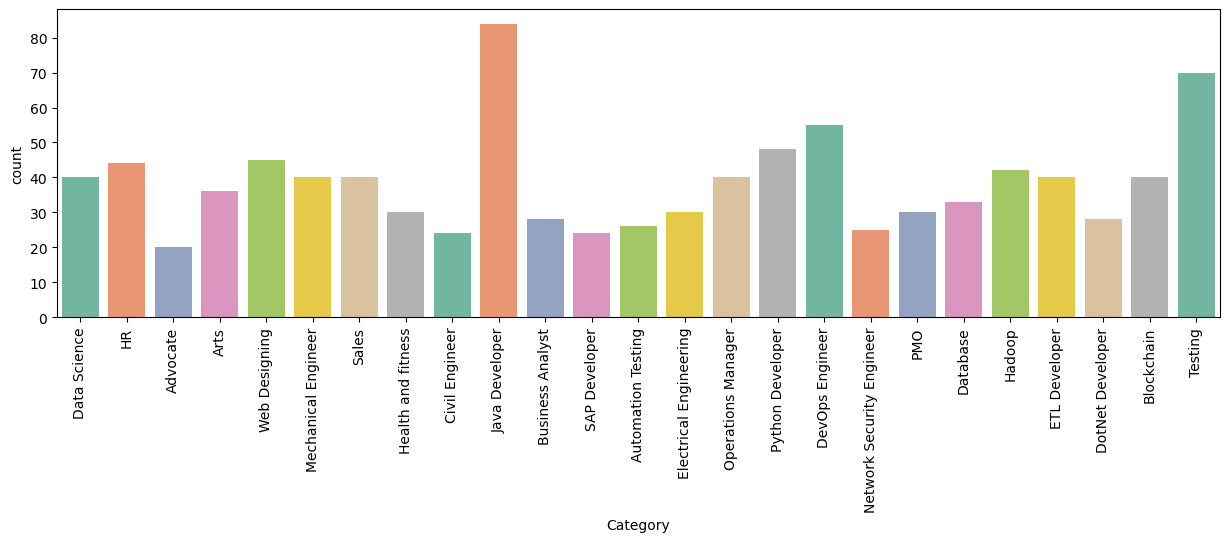

In [8]:
plt.figure(figsize= (15,4))
sns.countplot(x = df['Category'] , hue= df['Category'] , palette='Set2', legend= False)
plt.xticks(rotation = 90)
plt.show()

In [9]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

<IPython.core.display.Javascript object>

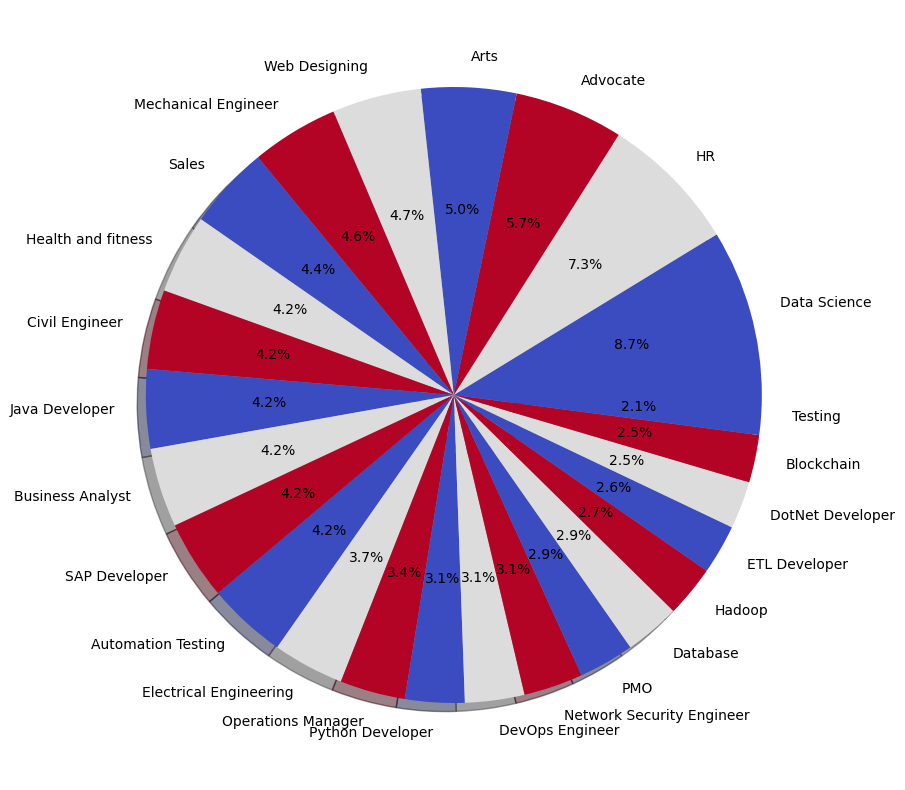

In [10]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()

plt.figure(figsize= (15,10))
plt.pie(counts, labels= labels, autopct= '%1.1f%%', shadow= True, colors=plt.cm.coolwarm(np.linspace(0,1,3)))
plt.show()

# Exploring Resume 

In [11]:
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [12]:
print(df['Resume'][0])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur

In [13]:
df["Category"][0]

'Data Science'

# Balance Classes (Categories)

In [14]:
# Check the original category distribution
print("Original Category Distribution:")
print(df['Category'].value_counts())

# Get the largest category size (i.e., the category with the maximum number of entries)
max_size = df['Category'].value_counts().max()

# Perform oversampling
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# Shuffle the dataset to avoid any order bias
df = balanced_df.sample(frac=1).reset_index(drop=True)

# Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
PMO                          84
Network Security Engineer    84
Arts  

# Cleaning Data 


1. URLs,
2. Hastags
3. Mentions
4. Special Letters
5. Punctuations

In [15]:
import re

def cleanResume(txt):
    cleanText = re.sub('http\S+\s*', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s*', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText



In [16]:
# Test case
cleanResume("my #### $ # #noorsaeed webiste like is this http://heloword and access it @gmail.com")
    

'my webiste like is this and a ess it '

In [17]:
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

In [18]:
print(df['Resume'][0])

CORE COMPETENCIES Maintain processes to ensure project management documentation reports and plans are relevant a urate and complete Report automation Dashboard preparation and sharing feedbacks basis on performance of Project Manager Forecasting data regarding future risks Project changes and updating the delivery team on timely basis Good understanding of project management lifecycle Proven excellence in Risk Management and control Good understanding of Software Development Lifecycle SDLC Ability to synthesize qualitative and quantitative data quickly and draw meaningful insights Knowledge of Programme Project Management methodologies with full project reporting and governance Ability to work with different cross functional stakeholders to establish and ensure a reliable and productive working relationship Strong time management and organizational skills Multitasking skills and ability to meet deadlines COMPUTER SKILLS AND CE IFICATION Advance knowledge in MS office 2013 and Macros SK

# Words into categorical values

In [19]:
df

,Category,Resume
0,PMO,CORE COMPETENCIES Maintain processes to ensure...
1,Network Security Engineer,Communication Skills My writing skills in Engl...
2,PMO,AREA OF EXPE ISE PROFILE Around 10 plus years ...
3,Arts,Operating Systems Windows XP Vista 07Educatio...
4,Advocate,SKILLS Knows English as native speaker IELTS O...
...,...,...
2095,Blockchain,SKILLS Bitcoin Ethereum Solidity Hyperledger B...
2096,Java Developer,Education Details January 2013 Master of Engin...
2097,Health and fitness,Education Details January 2018 M S Nutrition a...
2098,Data Science,Education Details MCA YMCAUST Faridabad Haryan...


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [21]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])


In [22]:
df

,Category,Resume
0,19,CORE COMPETENCIES Maintain processes to ensure...
1,17,Communication Skills My writing skills in Engl...
2,19,AREA OF EXPE ISE PROFILE Around 10 plus years ...
3,1,Operating Systems Windows XP Vista 07Educatio...
4,0,SKILLS Knows English as native speaker IELTS O...
...,...,...
2095,3,SKILLS Bitcoin Ethereum Solidity Hyperledger B...
2096,15,Education Details January 2013 Master of Engin...
2097,14,Education Details January 2018 M S Nutrition a...
2098,6,Education Details MCA YMCAUST Faridabad Haryan...


In [ ]:

''' Category uniques = (['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object) '''

df.Category.unique()

array([19, 17,  1,  0, 12, 15,  3, 14, 21,  2, 10, 11,  9,  7,  8,  4, 18,
       24, 23, 22,  5,  6, 13, 16, 20])

# Vactorization

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words= 'english')


tfidf.fit(df['Resume'])
required_text = tfidf.transform(df['Resume'])

In [25]:
required_text

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 373188 stored elements and shape (2100, 7351)>

In [26]:
df

,Category,Resume
0,19,CORE COMPETENCIES Maintain processes to ensure...
1,17,Communication Skills My writing skills in Engl...
2,19,AREA OF EXPE ISE PROFILE Around 10 plus years ...
3,1,Operating Systems Windows XP Vista 07Educatio...
4,0,SKILLS Knows English as native speaker IELTS O...
...,...,...
2095,3,SKILLS Bitcoin Ethereum Solidity Hyperledger B...
2096,15,Education Details January 2013 Master of Engin...
2097,14,Education Details January 2018 M S Nutrition a...
2098,6,Education Details MCA YMCAUST Faridabad Haryan...


# Splitting

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(required_text, df['Category'], test_size=0.2, random_state=42)

In [28]:
X_train.shape

(1680, 7351)

In [29]:
X_test.shape

(420, 7351)

# Now let's Train the Model and Print the Classification Report:

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure that X_train and X_test are dense if they are sparse
X_train = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# 1. Train KNeighborsClassifier
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0  

In [31]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Linear SVC
svc_model = OneVsRestClassifier(
    LinearSVC()
)

svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")


SVC Results:
Accuracy: 1.0000
Confusion Matrix:
[[18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0 

In [32]:
# 3. Train RandomForestClassifier 

rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


RandomForestClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0

# Save FIles 

In [33]:
import pickle

pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(svc_model, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

# Prediction System

In [34]:

# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = cleanResume(input_resume) 

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svc_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name

In [ ]:
myresume = '''Data Science Resume

Harsh

Email: [rahul.sharma@email.com](mailto:rahul.sharma@email.com) | Phone: +91-9876543210
LinkedIn: linkedin.com/in/rahulsharma | GitHub: github.com/rahulsharma

Professional Summary

Data Science enthusiast with hands-on experience in Python, SQL, Machine Learning, Exploratory Data Analysis, and data visualization. Experienced in developing predictive models and extracting actionable insights from structured datasets.

Technical Skills

* Python, SQL
* NumPy, Pandas, Matplotlib, Seaborn
* Scikit-learn
* Machine Learning
* Exploratory Data Analysis
* Data Cleaning & Preprocessing
* Power BI, Excel
* Git & GitHub

Projects

Customer Churn Prediction

* Cleaned and preprocessed customer datasets using Pandas.
* Performed EDA and feature engineering.
* Built classification models using Logistic Regression, Random Forest, and XGBoost.
* Evaluated models using accuracy, precision, recall, and F1-score.

Sales Data Analysis

* Analyzed sales trends using Python and SQL.
* Created interactive dashboards for business insights.

Education

B.Tech in Computer Science Engineering
ABC Institute of Technology | 2022–2026

Certifications

* Data Science with Python
* Machine Learning Fundamentals
* SQL for Data Analysis '''

pred(myresume)


'Data Science'

In [36]:
myresume2 = """
HARSH ANTLA

SOFTWARE DEVELOPER / BACKEND ENGINEER

SUMMARY
Computer Science Engineering student interested in software development
and backend engineering. Experienced in Python programming, REST APIs,
database management and application development.

SKILLS
Python, Java, C++, SQL, MySQL, FastAPI, REST API, Git, GitHub,
Object-Oriented Programming, Data Structures, Algorithms

PROJECTS
E-Commerce Backend
- Developed REST APIs using FastAPI.
- Implemented product, user and order management.
- Connected application with MySQL database.

Task Management Application
- Built backend APIs for creating and managing tasks.
- Implemented authentication and CRUD operations.

EDUCATION
B.Tech in Computer Science Engineering

CERTIFICATIONS
Python Programming
Backend Development

INTERESTS
Software Engineering, Backend Development, APIs
"""

pred(myresume2)

'Python Developer'

In [ ]:
myresume3 = """ Python Developer Resume

ANKUSH

Email: [aman.kumar@email.com](mailto:aman.kumar@email.com) | Phone: +91-9898765432
GitHub: github.com/amankumar | LinkedIn: linkedin.com/in/amankumar

Professional Summary

Python Developer with experience in developing backend applications, REST APIs, automation scripts, and database-driven applications. Strong knowledge of Python programming, FastAPI, Django, SQL, and Git.

Technical Skills

* Python
* Django, Flask, FastAPI
* REST APIs
* SQL, MySQL, PostgreSQL
* Pandas, NumPy
* Git & GitHub
* HTML, CSS, JavaScript
* Docker
* Linux

Projects

Employee Management API

* Developed REST APIs using FastAPI.
* Implemented CRUD operations for employee records.
* Integrated PostgreSQL database.
* Added API validation and error handling.

Web Scraping Automation

* Developed Python automation scripts using BeautifulSoup and Selenium.
* Extracted and processed data from websites.
* Stored processed data in CSV and database formats.

Professional Experience

Junior Python Developer

Tech Solutions Pvt. Ltd. | 2024–2026

* Developed Python-based backend applications.
* Created and maintained REST APIs.
* Fixed bugs and optimized application performance.
* Worked with SQL databases and Git.

Education

B.Tech in Computer Science Engineering
ABC University | 2020–2024

"""

pred(myresume3)

'Python Developer'

In [ ]:
my_resume3 = ''' Mechanical Engineer Resume

KHUSHI

Email: [rohit.singh@email.com](mailto:rohit.singh@email.com) | Phone: +91-9765432109
LinkedIn: linkedin.com/in/rohitsingh

Professional Summary

Mechanical Engineer with experience in manufacturing, production planning, mechanical design, quality control, and maintenance. Skilled in CAD software, engineering drawings, and manufacturing processes.

Technical Skills

* AutoCAD
* SolidWorks
* CATIA
* Mechanical Design
* Manufacturing Processes
* Production Planning
* Quality Control
* Preventive Maintenance
* Engineering Drawing
* CNC Machines
* MS Excel

Professional Experience

Mechanical Engineer

ABC Manufacturing Pvt. Ltd. | 2023–2026

* Designed mechanical components using AutoCAD and SolidWorks.
* Prepared engineering drawings and technical documentation.
* Monitored manufacturing and production processes.
* Performed quality inspections of mechanical components.
* Assisted in preventive maintenance activities.
* Coordinated with production and quality teams.

Mechanical Engineering Intern

XYZ Industries | 2022–2023

* Assisted engineers in production activities.
* Studied CNC machining and manufacturing processes.
* Supported quality inspection and documentation.

Education

B.Tech in Mechanical Engineering
ABC Institute of Engineering | 2020–2024

Certifications

* AutoCAD Certification
* SolidWorks Design
* CNC Manufacturing Fundamentals
'''

pred(my_resume3)

'Mechanical Engineer'